In [26]:
%load_ext autoreload
%autoreload 2
%time

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
CPU times: user 5 µs, sys: 0 ns, total: 5 µs
Wall time: 8.34 µs


In [27]:
import sys, os
sys.path.append("../../")  # if needed
import pandas as pd
import data_loading as dl
import numpy as np
import matplotlib.pyplot as plt
from cc0pi_cached import _apply_cc0pi_cached, _df_fp, _hash_file, _code_fp, generate_hash, load_runs_with_cc0pi_bdt


In [28]:
#Load the OG run (no BDT yet)
rundata, weights, data_pot = dl.load_runs(
    ["1"],
    enable_cache=True,
    data="bnb",
    loadshowervariables=False,
    loadnumuvariables=True,
    load_numu_tki=False,
    loadpi0variables=False,
    loadrecoveryvars=False,
    loadsystematics=True,
    blinded=True,
    use_bdt=False,
)
%time

Loading run 1
CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 8.58 µs


In [29]:
mc_full       = rundata["mc"]
mc_small_bdt  = mc_full.head(50000).copy()
#print(rundata.keys())

In [30]:
from numu_tki.cc0pi_analyzer import apply_ccnp0pi_stv

model_path = "/exp/uboone/app/users/rlalnunt/PELEE_BDT/cc0pi_fstrack_pid_softprob.json"
mc = apply_ccnp0pi_stv(mc_small_bdt.copy(), model_path=model_path)

# # for key in ['mc','nue','ext']:  # skip 'data' if blinded
# #     rundata[key] = apply_ccnp0pi_stv(rundata[key].copy(), model_path=model_path)

# # mc = rundata['mc']

# for key in ['mc', 'nue', 'drt']:
#     df = rundata[key]

#     # pick any subset
#     idx = df.head(100).index
#     # run the BDT only on the small slice
#     mc = apply_ccnp0pi_stv(df.loc[idx].copy(), model_path=model_path)


In [31]:
#print(mc)

In [32]:
sel_mc_1mu1p = mc[mc['sel_CC1p0pi'] == True ] # Truth-Level Study
pre_mc_1mu1p = mc[mc['sel_CCNp0pi'] == True ]

0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
           ...   
49995         NaN
49996         NaN
49997         NaN
49998         NaN
49999    0.909987
Name: Ecal, Length: 50000, dtype: float64


(array([6.830e+02, 1.129e+03, 6.400e+02, 2.330e+02, 5.300e+01, 1.900e+01,
        5.000e+00, 3.000e+00, 1.000e+00, 3.000e+00]),
 array([0.20357815, 0.5493438 , 0.89510945, 1.24087511, 1.58664076,
        1.93240641, 2.27817207, 2.62393772, 2.96970338, 3.31546903,
        3.66123468]),
 <BarContainer object of 10 artists>)

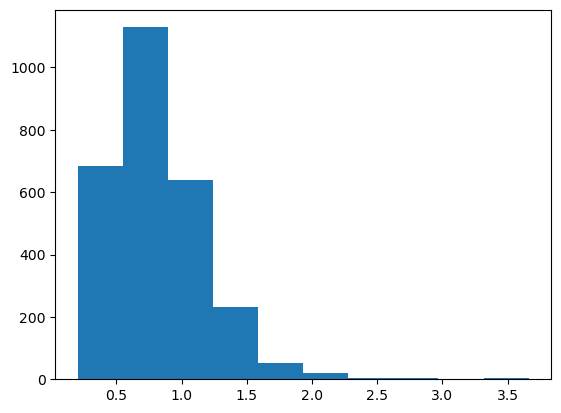

In [33]:
sel = mc['Ecal']
print(sel)
plt.hist(sel)

### ECAL Resolution

648


/nashome/r/rlalnunt/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == "":
/nashome/r/rlalnunt/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  del sys.path[0]
/nashome/r/rlalnunt/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from 

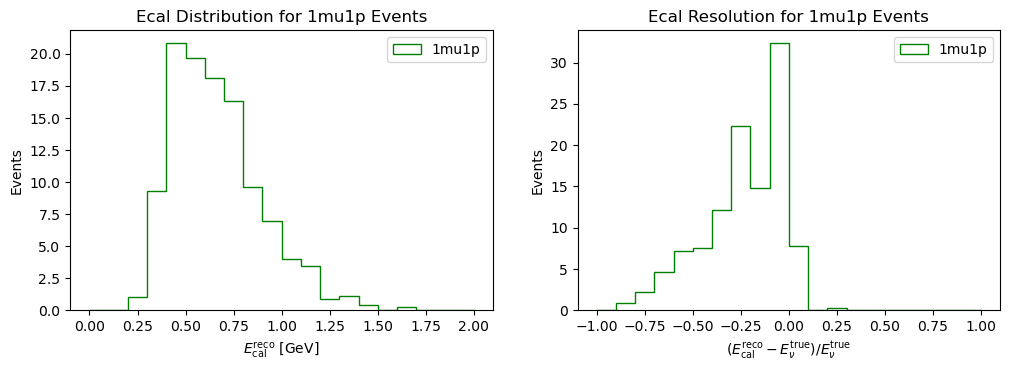

In [62]:
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)

# Compute reco neutrino energy via Ecal method
reco_ecal_energy   = sel_mc_1mu1p["Ecal"].values
true_nu_energy     = sel_mc_1mu1p["nu_e"].values
# Compute Ecal resolution
ecal_resolution_1mu1p = (reco_ecal_energy - true_nu_energy) / true_nu_energy
print(len(ecal_resolution_1mu1p))

# Add to DataFrame
sel_mc_1mu1p['Ecal_1mu1p'] = ecal_resolution_1mu1p
sel_mc_1mu1p['E_Reco'] = reco_ecal_energy
sel_mc_1mu1p['E_True'] = true_nu_energy

plt.hist(sel_mc_1mu1p['E_Reco'], bins=20, weights=sel_mc_1mu1p['weights'], range=(0, 2),
         histtype='step', linestyle='-', color='Green', label='1mu1p')
plt.xlabel('$E_{\mathrm{cal}}^{\mathrm{reco}}$ [GeV]')
plt.ylabel('Events')
plt.title('Ecal Distribution for 1mu1p Events')
plt.legend()

plt.subplot(2, 2, 2)
plt.hist(sel_mc_1mu1p['Ecal_1mu1p'], bins=20, weights=sel_mc_1mu1p['weights'], range=(-1, 1),
         histtype='step', linestyle='-', color='Green', label='1mu1p')
plt.xlabel(r"$(E_{\mathrm{cal}}^{\mathrm{reco}} - E_\nu^{\mathrm{true}})/E_\nu^{\mathrm{true}}$")
plt.ylabel('Events')
plt.title('Ecal Resolution for 1mu1p Events')
plt.legend()

In [63]:
#rundata_mc = {k: v for k, v in rundata.items() if k not in ("data", "ext")}

In [64]:
selection    = "sel_CC1p0pi"  
preselection = "sel_CCNp0pi"   

In [41]:
import pandas as pd
import numpy as np
from microfit.histogram import Binning, RunHistGenerator

stub = pd.DataFrame({
    "Ecal":         pd.Series([], dtype=float),
    "sel_CCNp0pi":  pd.Series([], dtype=bool),
    "sel_CC1p0pi":  pd.Series([], dtype=bool),
})

# rundata_stub = {
#     "data": stub.copy(),
#     "ext":  stub.copy(),
#     "mc":   mc,               #analyzed MC with Ecal & selection flags
# }
empty_like_mc = mc.head(0).copy()

rundata_stub = {
    "dirt": empty_like_mc.copy(),
    "data": empty_like_mc.copy(),  # ok even if blinded; it’s empty
    "ext":  empty_like_mc.copy(),
    "mc":   mc,                    # your analyzed MC
}

binning_def = ("Ecal", 20, (0.0, 2.0), r"Ecal (GeV)")
binning = Binning.from_config(*binning_def)
binning.label = "BDT_1mu1p"
binning.set_selection(selection, preselection)
binning

signal_generator_1mu1p = RunHistGenerator(
    rundata_stub,
    binning,
    data_pot=data_pot,
    showdata=False,   # optional
)
total_prediction_1mu1p = signal_generator_1mu1p.get_total_prediction(include_multisim_errors=True)


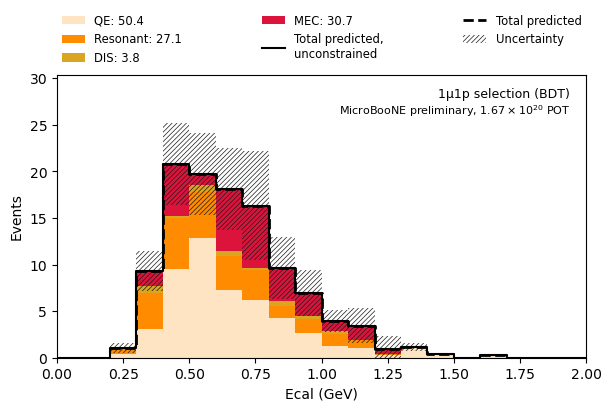

In [42]:
from microfit.run_plotter import RunHistPlotter

plotter = RunHistPlotter(signal_generator_1mu1p)
ax = plotter.plot(
    category_column="interaction",
    include_multisim_errors=True,
    add_ext_error_floor=False,
    show_data_mc_ratio=False,
    show_chi_square=False,
)

### ECAL Systematics

/nashome/r/rlalnunt/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  



Using variable: ECal_all
bin counts: [ 0.          0.          4.83229607 20.24005699 22.05842883 16.20228446
 12.30676472  9.38325886  5.91939192  2.93619564  1.61659387  1.01933172
  0.29734695  0.2862712   0.          0.          0.        ]
stat error: [       inf        inf 0.20633115 0.12552409 0.09570818 0.09541981
 0.11881568 0.19437006 0.19604329 0.23260032 0.2896077  0.37911727
 0.70010007 0.70753397        inf        inf        inf]



/nashome/r/rlalnunt/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:67: RuntimeWarning: divide by zero encountered in true_divide


genie error: [       nan        nan 0.11572301 0.16449406 0.12054252 0.11435026
 0.14957929 0.16215135 0.14475044 0.15864621 0.20151492 0.19954015
 0.11945763 0.20374102        nan        nan        nan]

genie unisim error: [       nan        nan 0.08628598 0.10898149 0.02823211 0.06302436
 0.05954947 0.16961046 0.07749275 0.15155615 0.01052579 0.26086591
 0.74362607 0.03166523        nan        nan        nan]



/nashome/r/rlalnunt/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:88: RuntimeWarning: invalid value encountered in true_divide
/nashome/r/rlalnunt/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:94: RuntimeWarning: invalid value encountered in true_divide


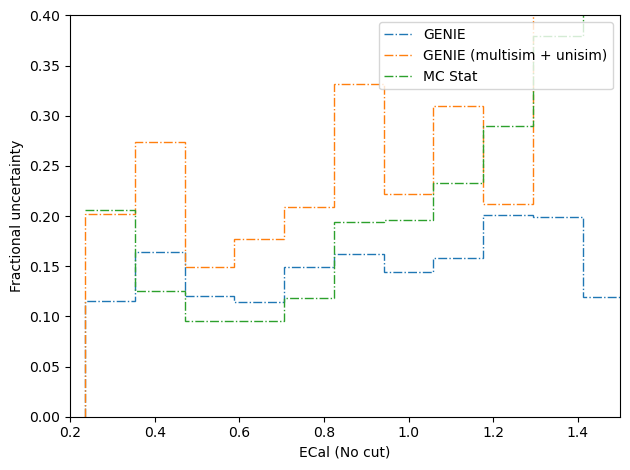


Using variable: ECal_pT04
bin counts: [ 0.          0.          4.02007595 17.04556722 17.24368663 12.37962646
  9.56613084  7.5637002   3.70867766  2.36244008  1.20867941  1.01933172
  0.29734695  0.2862712   0.          0.          0.        ]
stat error: [       inf        inf 0.23379448 0.14275919 0.11276592 0.10967905
 0.12383889 0.23145469 0.21104734 0.26263861 0.33456545 0.37911727
 0.70010007 0.70753397        inf        inf        inf]

genie error: [       nan        nan 0.12578246 0.17171203 0.13209205 0.11956158
 0.14904253 0.17577732 0.114611   0.16617589 0.21828491 0.19954015
 0.11945763 0.20374102        nan        nan        nan]

genie unisim error: [       nan        nan 0.10376621 0.14671749 0.0231352  0.06677557
 0.0989403  0.21015605 0.04237909 0.13180189 0.01364161 0.26086591
 0.74362607 0.03166523        nan        nan        nan]



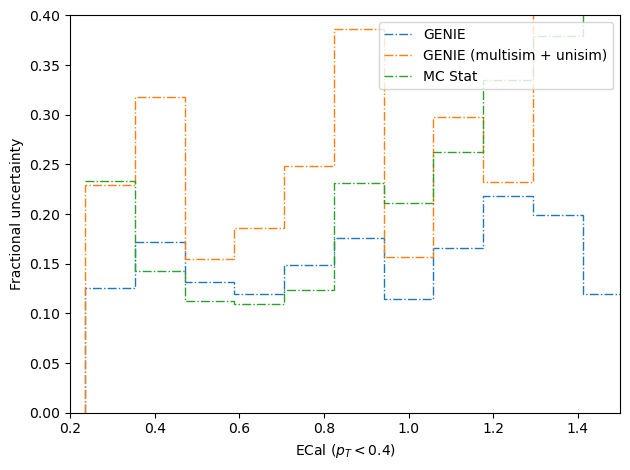


Using variable: ECal_pT03
bin counts: [ 0.          0.          3.15694415 14.14017581 14.13172398 10.43785377
  8.88052465  6.49809962  2.89733677  1.56594424  0.8181214   1.01933172
  0.29734695  0.2862712   0.          0.          0.        ]
stat error: [       inf        inf 0.27573666 0.14691911 0.12939322 0.11801076
 0.12883381 0.26307475 0.24467679 0.322281   0.41030377 0.37911727
 0.70010007 0.70753397        inf        inf        inf]

genie error: [       nan        nan 0.13919361 0.16284867 0.14310257 0.12060605
 0.15227312 0.19424049 0.10393357 0.14171526 0.19542615 0.19954015
 0.11945763 0.20374102        nan        nan        nan]

genie unisim error: [       nan        nan 0.13226267 0.12212659 0.06366975 0.05712847
 0.1064304  0.24475041 0.06338739 0.17214707 0.02015389 0.26086591
 0.74362607 0.03166523        nan        nan        nan]



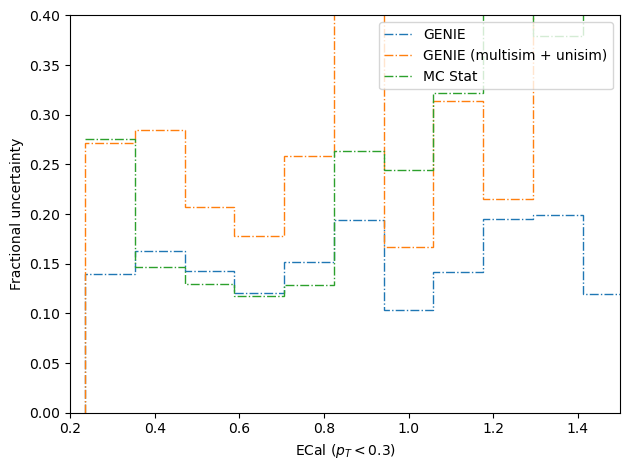


Using variable: ECal_pT02
bin counts: [ 0.          0.          1.74332447 10.45373516 11.62563845  7.95039661
  6.65548018  3.74399779  2.15001616  1.46209184  0.6879354   1.01933172
  0.29734695  0.2862712   0.          0.          0.        ]
stat error: [       inf        inf 0.29022583 0.18665378 0.14892923 0.13609252
 0.15002934 0.32073596 0.29030131 0.33778525 0.44975896 0.37911727
 0.70010007 0.70753397        inf        inf        inf]

genie error: [       nan        nan 0.15033325 0.19843419 0.14295353 0.11639514
 0.15487109 0.2183767  0.11329648 0.12502957 0.19817717 0.19954015
 0.11945763 0.20374102        nan        nan        nan]

genie unisim error: [       nan        nan 0.01307958 0.18428571 0.1107955  0.04066051
 0.0849749  0.18303361 0.08392835 0.16779298 0.02396785 0.26086591
 0.74362607 0.03166523        nan        nan        nan]



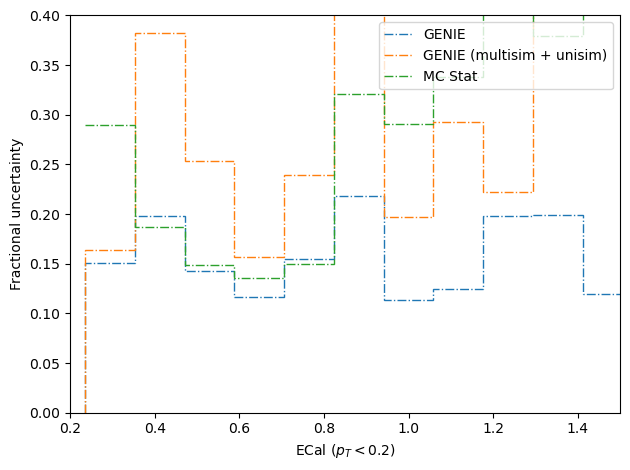

In [65]:
from microfit import histogram as hist
from microfit import detsys


reco_delta_pT   = sel_mc_1mu1p["delta_pT"].values
sel_mc_1mu1p['delta_pT'] = reco_delta_pT

for k, df in rundata.items():
    if df is None:
        continue
    # ECal for all events
    df["ECal_all"] = (
        sel_mc_1mu1p["Ecal"]
    )
    df["delta_pT"] = (
        sel_mc_1mu1p["delta_pT"]
    )
    # ECal only for pT<0.4
    mask = df["delta_pT"] < 0.4
    df["ECal_pT04"] = np.nan
    df.loc[mask, "ECal_pT04"] = df.loc[mask, "ECal_all"]
    
    mask = df["delta_pT"] < 0.3
    df["ECal_pT03"] = np.nan
    df.loc[mask, "ECal_pT03"] = df.loc[mask, "ECal_all"]
    
    mask = df["delta_pT"] < 0.2
    df["ECal_pT02"] = np.nan
    df.loc[mask, "ECal_pT02"] = df.loc[mask, "ECal_all"]
    


IntegratedFlux = 1

#edges = np.linspace(0.0, 1.5, 15) # OG
edges = np.linspace(0.0, 2.0, 18)
my_vars = [
    ("ECal_all",  edges, r"ECal (No cut)"),
    ("ECal_pT04", edges, r"ECal ($p_T<0.4$)"),
    ("ECal_pT03", edges, r"ECal ($p_T<0.3$)"),
    ("ECal_pT02", edges, r"ECal ($p_T<0.2$)"),
]

for var_name, var_edges, var_tex in my_vars:
    #  Binning from Ecal new df column 
    binning = hist.Binning(variable=var_name, bin_edges=var_edges, label=var_name, variable_tex=var_tex)
    print(f"\nUsing variable: {var_name}")

    # NOMINAL
    # Stats error 
    signal_generator_stat = hist.RunHistGenerator(
        rundata,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        detvar_data=None,                  # <-- no det sys
        uncertainty_defaults=None,
        #normalization_uncertainty=None,
    )
 
    total_prediction_stat = signal_generator_stat.get_total_prediction(include_multisim_errors=False, add_precomputed_detsys=False)
    bin_counts = total_prediction_stat.bin_counts # Not Sure about this --> Needs verfication
    print('bin counts:', bin_counts)
    flux_norm_total_prediction_stat = total_prediction_stat / IntegratedFlux
    stat_cov = flux_norm_total_prediction_stat.covariance_matrix
    stat_error = np.sqrt(np.diagonal(stat_cov)) / bin_counts
    print('stat error:', stat_error)
    print()
    
    # Multisim errors:
    signal_generator_multisim = hist.RunHistGenerator(
        rundata,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        sideband_generator=None,
        uncertainty_defaults=None,
        detvar_data=None,
        #normalization_uncertainty=None
    )
    
    mc_hist_generator = signal_generator_multisim.mc_hist_generator
    
    # GENIE error
    genie_cov = (mc_hist_generator.calculate_multisim_uncertainties(multisim_weight_column="weightsGenie")) / IntegratedFlux**2
    genie_error = np.sqrt(np.diagonal(genie_cov)) / bin_counts
    print('genie error:', genie_error)
    print()
    
    # GENIE Unisim
    genie_unisim_cov = (mc_hist_generator.calculate_unisim_uncertainties()) / IntegratedFlux**2
    genie_unisim_error = np.sqrt(np.diagonal(genie_unisim_cov)) / bin_counts
    print('genie unisim error:', genie_unisim_error)
    print()
    
    
    # Fractional uncertainty plot
    fig, ax = plt.subplots()
    ax.stairs(genie_error, var_edges, label='GENIE', linestyle='dashdot')
    ax.stairs(genie_error+genie_unisim_error, var_edges, label='GENIE (multisim + unisim)', linestyle='dashdot')
    ax.stairs(stat_error, var_edges, label='MC Stat', linestyle='dashdot')
    ax.set_xlabel(var_tex)
    ax.set_ylabel('Fractional uncertainty')
    ax.legend(loc="best")
    ax.set_ylim(0,.4)
    ax.set_xlim(0.20,1.50)
    plt.tight_layout()
    #plt.savefig(f'analysis_plots/errors/noDet_{var_name}_{len(bin_edges)-1}bins.png', bbox_inches='tight')
    plt.show()
    plt.close()

### BRUTE FORCE INJECTING BDT ntuples into OG DF

In [44]:
# --- already did this part: load runs and build a small BDT sample ---
# rundata, weights, data_pot = dl.load_runs(..., use_bdt=False)
# mc_full       = rundata["mc"]
# mc_small_bdt  = mc_full.head(50000).copy()
# from numu_tki.cc0pi_analyzer import apply_ccnp0pi_stv
# model_path = "/exp/uboone/app/users/rlalnunt/PELEE_BDT/cc0pi_fstrack_pid_softprob.json"
# mc_bdt = apply_ccnp0pi_stv(mc_small_bdt.copy(), model_path=model_path)
# mc_bdt now has: Ecal, delta_pT, sel_CCNp0pi, sel_CC1p0pi, ...

# Make sure the target columns exist on every rundata DF (as NaN) ---
needed_cols = ["Ecal", "delta_pT", "sel_CCNp0pi", "sel_CC1p0pi"]
for key, df in rundata.items():
    if df is None: 
        continue
    for c in needed_cols:
        if c not in df.columns:
            df[c] = np.nan  # booleans can stay NaN;

# Inject the BDT outputs ONLY into the matching rows of rundata['mc'] ---
mc_main = rundata["mc"]
inject_cols = ["Ecal", "delta_pT", "sel_CCNp0pi", "sel_CC1p0pi"]
overlap_idx = mc_main.index.intersection(mc.index)
for c in inject_cols:
    mc_main.loc[overlap_idx, c] = mc.loc[overlap_idx, c].values

#  Aslo, one-shot join instead of the loop:
# mc_main = mc_main.join(mc_bdt[inject_cols], how="left", rsuffix="_bdt")
# # and then, if join created *_bdt columns, rename or swap as you like.

# Build ECal variables ON THE MC ITSELF ---
m = rundata["mc"]
# sanity checks
assert "Ecal" in m.columns, "Ecal not present on MC after injection"
assert "delta_pT" in m.columns, "delta_pT not present on MC after injection"

m["ECal_all"]  = m["Ecal"]
m["ECal_pT04"] = np.where(m["delta_pT"] < 0.40, m["Ecal"], np.nan)
m["ECal_pT03"] = np.where(m["delta_pT"] < 0.30, m["Ecal"], np.nan)
m["ECal_pT02"] = np.where(m["delta_pT"] < 0.20, m["Ecal"], np.nan)



Using variable: ECal_all
bin counts: [ 0.          0.          4.83229607 20.24005699 22.05842883 16.20228446
 12.30676472  9.38325886  5.91939192  2.93619564  1.61659387  1.01933172
  0.29734695  0.2862712   0.          0.          0.        ]
stat error: [       inf        inf 0.20633115 0.12552409 0.09570818 0.09541981
 0.11881568 0.19437006 0.19604329 0.23260032 0.2896077  0.37911727
 0.70010007 0.70753397        inf        inf        inf]



/nashome/r/rlalnunt/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:39: RuntimeWarning: divide by zero encountered in true_divide


genie error: [       nan        nan 0.11572301 0.16449406 0.12054252 0.11435026
 0.14957929 0.16215135 0.14475044 0.15864621 0.20151492 0.19954015
 0.11945763 0.20374102        nan        nan        nan]

genie unisim error: [       nan        nan 0.08628598 0.10898149 0.02823211 0.06302436
 0.05954947 0.16961046 0.07749275 0.15155615 0.01052579 0.26086591
 0.74362607 0.03166523        nan        nan        nan]



/nashome/r/rlalnunt/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:60: RuntimeWarning: invalid value encountered in true_divide
/nashome/r/rlalnunt/miniforge3/envs/python3LEE/lib/python3.7/site-packages/ipykernel_launcher.py:66: RuntimeWarning: invalid value encountered in true_divide


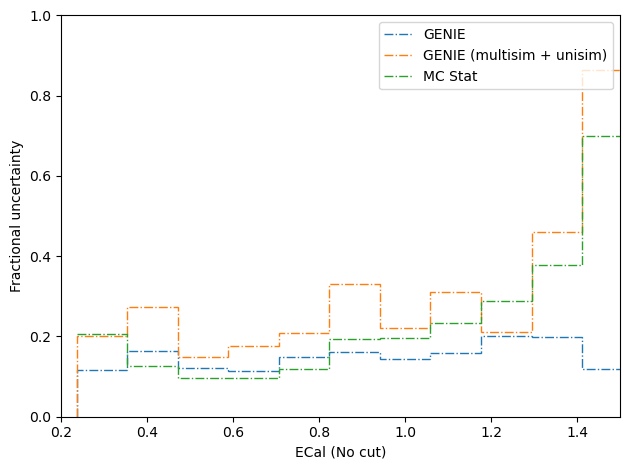


Using variable: ECal_pT04
bin counts: [ 0.          0.          4.02007595 17.04556722 17.24368663 12.37962646
  9.56613084  7.5637002   3.70867766  2.36244008  1.20867941  1.01933172
  0.29734695  0.2862712   0.          0.          0.        ]
stat error: [       inf        inf 0.23379448 0.14275919 0.11276592 0.10967905
 0.12383889 0.23145469 0.21104734 0.26263861 0.33456545 0.37911727
 0.70010007 0.70753397        inf        inf        inf]

genie error: [       nan        nan 0.12578246 0.17171203 0.13209205 0.11956158
 0.14904253 0.17577732 0.114611   0.16617589 0.21828491 0.19954015
 0.11945763 0.20374102        nan        nan        nan]

genie unisim error: [       nan        nan 0.10376621 0.14671749 0.0231352  0.06677557
 0.0989403  0.21015605 0.04237909 0.13180189 0.01364161 0.26086591
 0.74362607 0.03166523        nan        nan        nan]



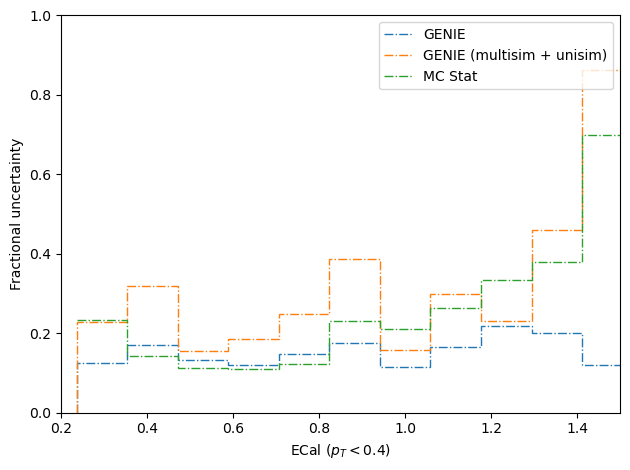


Using variable: ECal_pT03
bin counts: [ 0.          0.          3.15694415 14.14017581 14.13172398 10.43785377
  8.88052465  6.49809962  2.89733677  1.56594424  0.8181214   1.01933172
  0.29734695  0.2862712   0.          0.          0.        ]
stat error: [       inf        inf 0.27573666 0.14691911 0.12939322 0.11801076
 0.12883381 0.26307475 0.24467679 0.322281   0.41030377 0.37911727
 0.70010007 0.70753397        inf        inf        inf]

genie error: [       nan        nan 0.13919361 0.16284867 0.14310257 0.12060605
 0.15227312 0.19424049 0.10393357 0.14171526 0.19542615 0.19954015
 0.11945763 0.20374102        nan        nan        nan]

genie unisim error: [       nan        nan 0.13226267 0.12212659 0.06366975 0.05712847
 0.1064304  0.24475041 0.06338739 0.17214707 0.02015389 0.26086591
 0.74362607 0.03166523        nan        nan        nan]



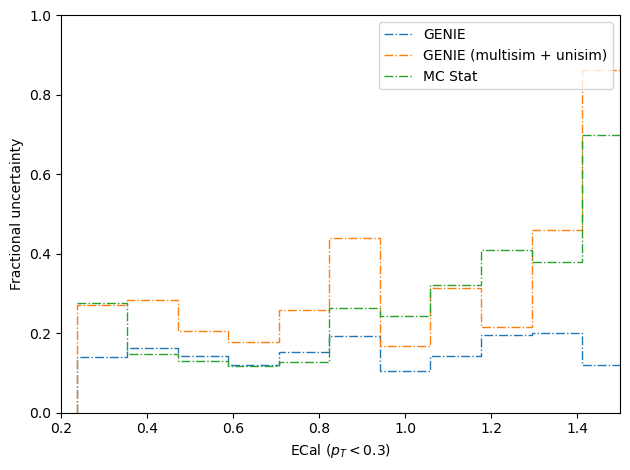


Using variable: ECal_pT02
bin counts: [ 0.          0.          1.74332447 10.45373516 11.62563845  7.95039661
  6.65548018  3.74399779  2.15001616  1.46209184  0.6879354   1.01933172
  0.29734695  0.2862712   0.          0.          0.        ]
stat error: [       inf        inf 0.29022583 0.18665378 0.14892923 0.13609252
 0.15002934 0.32073596 0.29030131 0.33778525 0.44975896 0.37911727
 0.70010007 0.70753397        inf        inf        inf]

genie error: [       nan        nan 0.15033325 0.19843419 0.14295353 0.11639514
 0.15487109 0.2183767  0.11329648 0.12502957 0.19817717 0.19954015
 0.11945763 0.20374102        nan        nan        nan]

genie unisim error: [       nan        nan 0.01307958 0.18428571 0.1107955  0.04066051
 0.0849749  0.18303361 0.08392835 0.16779298 0.02396785 0.26086591
 0.74362607 0.03166523        nan        nan        nan]



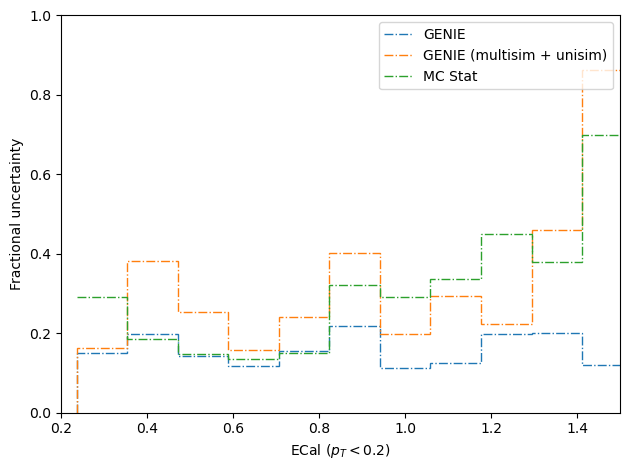

In [45]:
from microfit import histogram as hist
from microfit import detsys


IntegratedFlux = 1

#edges = np.linspace(0.0, 1.5, 15) # OG
edges = np.linspace(0.0, 2.0, 18)
my_vars = [
    ("ECal_all",  edges, r"ECal (No cut)"),
    ("ECal_pT04", edges, r"ECal ($p_T<0.4$)"),
    ("ECal_pT03", edges, r"ECal ($p_T<0.3$)"),
    ("ECal_pT02", edges, r"ECal ($p_T<0.2$)"),
]

for var_name, var_edges, var_tex in my_vars:
    #  Binning from Ecal new df column 
    binning = hist.Binning(variable=var_name, bin_edges=var_edges, label=var_name, variable_tex=var_tex)
    print(f"\nUsing variable: {var_name}")

    # NOMINAL
    # Stats error 
    signal_generator_stat = hist.RunHistGenerator(
        rundata,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        detvar_data=None,                  # <-- no det sys
        uncertainty_defaults=None,
        #normalization_uncertainty=None,
    )
 
    total_prediction_stat = signal_generator_stat.get_total_prediction(include_multisim_errors=False, add_precomputed_detsys=False)
    bin_counts = total_prediction_stat.bin_counts # Not Sure about this --> Needs verfication
    print('bin counts:', bin_counts)
    flux_norm_total_prediction_stat = total_prediction_stat / IntegratedFlux
    stat_cov = flux_norm_total_prediction_stat.covariance_matrix
    stat_error = np.sqrt(np.diagonal(stat_cov)) / bin_counts
    print('stat error:', stat_error)
    print()
    
    # Multisim errors:
    signal_generator_multisim = hist.RunHistGenerator(
        rundata,
        binning.copy(),
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        sideband_generator=None,
        uncertainty_defaults=None,
        detvar_data=None,
        #normalization_uncertainty=None
    )
    
    mc_hist_generator = signal_generator_multisim.mc_hist_generator
    
    # GENIE error
    genie_cov = (mc_hist_generator.calculate_multisim_uncertainties(multisim_weight_column="weightsGenie")) / IntegratedFlux**2
    genie_error = np.sqrt(np.diagonal(genie_cov)) / bin_counts
    print('genie error:', genie_error)
    print()
    
    # GENIE Unisim
    genie_unisim_cov = (mc_hist_generator.calculate_unisim_uncertainties()) / IntegratedFlux**2
    genie_unisim_error = np.sqrt(np.diagonal(genie_unisim_cov)) / bin_counts
    print('genie unisim error:', genie_unisim_error)
    print()
    
    
    # Fractional uncertainty plot
    fig, ax = plt.subplots()
    ax.stairs(genie_error, var_edges, label='GENIE', linestyle='dashdot')
    ax.stairs(genie_error+genie_unisim_error, var_edges, label='GENIE (multisim + unisim)', linestyle='dashdot')
    ax.stairs(stat_error, var_edges, label='MC Stat', linestyle='dashdot')
    ax.set_xlabel(var_tex)
    ax.set_ylabel('Fractional uncertainty')
    ax.legend(loc="best")
    ax.set_ylim(0,1.0)
    ax.set_xlim(0.20,1.50)
    plt.tight_layout()
    #plt.savefig(f'analysis_plots/errors/noDet_{var_name}_{len(bin_edges)-1}bins.png', bbox_inches='tight')
    plt.show()
    plt.close()

##### PLOT SEPARATELY


Using variable: ECal_all  [Reco ECal (No cut)]

Using variable: ECal_pT04  [Reco ECal ($p_T<0.4$)]

Using variable: ECal_pT03  [Reco ECal ($p_T<0.3$)]

Using variable: ECal_pT02  [Reco ECal ($p_T<0.2$)]


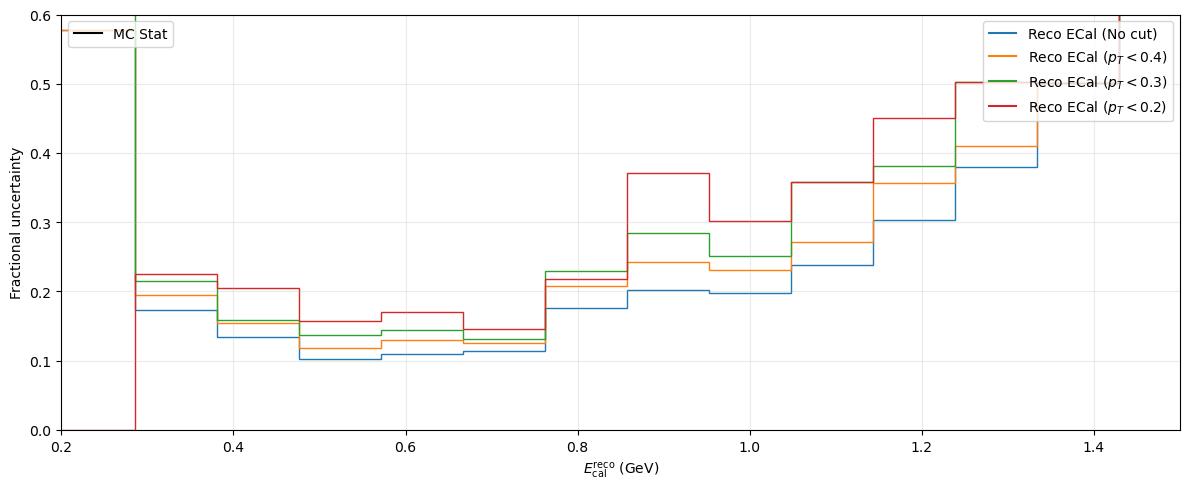

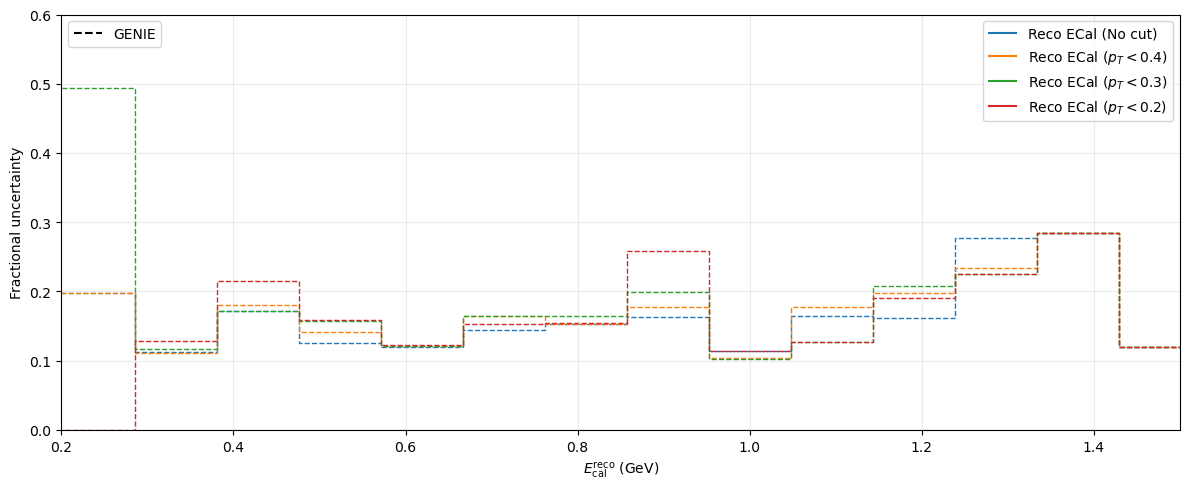

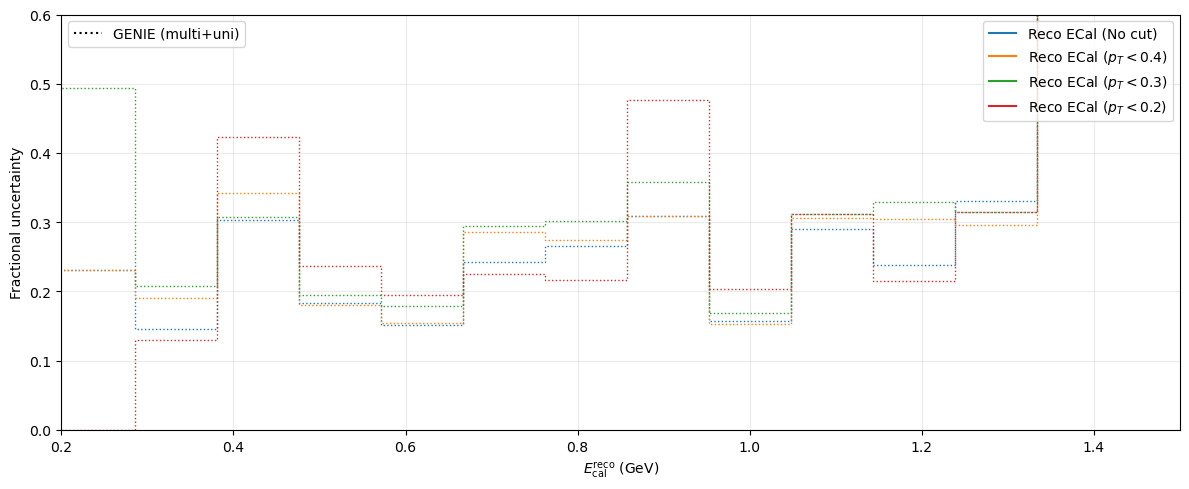

In [66]:
### DEFINE
from matplotlib.lines import Line2D

edges_ref = np.linspace(0.0, 2.0, 22)
variants = [
    ("ECal_all",  edges_ref, r"Reco ECal (No cut)"),
    ("ECal_pT04", edges_ref, r"Reco ECal ($p_T<0.4$)"),
    ("ECal_pT03", edges_ref, r"Reco ECal ($p_T<0.3$)"),
    ("ECal_pT02", edges_ref, r"Reco ECal ($p_T<0.2$)"),
]

# collectors for your family plots
curves_stat  = {}
curves_genie = {}
curves_genieU = {}

for var_name, var_edges, var_label in variants:
    print(f"\nUsing variable: {var_name}  [{var_label}]")
    binning = hist.Binning(variable=var_name, bin_edges=var_edges, label=var_name, variable_tex=var_label)

    # --- stats-only
    sg_stat = hist.RunHistGenerator(
        rundata, binning.copy(), data_pot=data_pot,
        selection=selection, preselection=preselection,
        detvar_data=None, uncertainty_defaults=None, showdata=False
    )
    tot_stat   = sg_stat.get_total_prediction(include_multisim_errors=False, add_precomputed_detsys=False)
    counts     = tot_stat.bin_counts.astype(float)
    safe_counts = np.where(counts > 0, counts, np.inf)

    stat_cov = (tot_stat / 1.0).covariance_matrix  # IntegratedFlux=1
    stat_err = np.sqrt(np.clip(np.diag(stat_cov), 0, None)) / safe_counts
    curves_stat[var_label] = stat_err

    # --- GENIE (multisim + unisim)
    sg_ms = hist.RunHistGenerator(
        rundata, binning.copy(), data_pot=data_pot,
        selection=selection, preselection=preselection,
        detvar_data=None, uncertainty_defaults=None, showdata=False
    )
    mch = sg_ms.mc_hist_generator

    # multisim only
    try:
        g_cov   = mch.calculate_multisim_uncertainties(multisim_weight_column="weightsGenie")
        g_err   = np.sqrt(np.clip(np.diag(g_cov), 0, None)) / safe_counts
    except Exception as e:
        print(f"[warn] GENIE multisim failed: {e}")
        g_err = np.zeros_like(counts)
    curves_genie[var_label] = g_err

    # multisim + unisim
    try:
        gu_cov  = mch.calculate_unisim_uncertainties()
        gu_err  = np.sqrt(np.clip(np.diag(gu_cov), 0, None)) / safe_counts
    except Exception as e:
        print(f"[warn] GENIE unisim failed: {e}")
        gu_err = np.zeros_like(counts)

    curves_genieU[var_label] = g_err + gu_err

### PLOT FUNCTION:    
variant_colors = {
    r"Reco ECal (No cut)"    : "C0",
    r"Reco ECal ($p_T<0.4$)" : "C1",
    r"Reco ECal ($p_T<0.3$)" : "C2",
    r"Reco ECal ($p_T<0.2$)" : "C3",
}

def plot_family(title, curves_dict, linestyle, edges_ref, xlim=(0.2, 1.5), ylim=(0.0, 0.6), figsize=(12,5)):
    fig, ax = plt.subplots(figsize=figsize)

    color_handles = []
    for lbl, color in variant_colors.items():
        if lbl not in curves_dict:
            continue
        y = curves_dict[lbl]
        if y is None or len(y) != len(edges_ref) - 1:
            # skip malformed entries quietly
            continue
        ax.stairs(y, edges_ref, color=color, linestyle=linestyle, label=None)
        color_handles.append(Line2D([0],[0], color=color, linestyle='-', label=lbl))

    # left legend = style (title); right legend = color map of variants
    style_handle = [Line2D([0],[0], color="black", linestyle=linestyle, label=title)]
    leg1 = ax.legend(handles=style_handle, loc="upper left")
    ax.add_artist(leg1)
    if color_handles:
        ax.legend(handles=color_handles, loc="upper right", ncol=1)

    ax.set_xlabel(r"$E_{\mathrm{cal}}^{\mathrm{reco}}$ (GeV)")
    ax.set_ylabel("Fractional uncertainty")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show() 
    
# ---- PLOT ----
plot_family("MC Stat",            curves_stat,   "-",  edges_ref, xlim=(0.2,1.5), ylim=(0,0.6) )
plot_family("GENIE",              curves_genie,  "--", edges_ref, xlim=(0.2,1.5), ylim=(0,0.6) )
plot_family("GENIE (multi+uni)",  curves_genieU, ":",  edges_ref, xlim=(0.2,1.5), ylim=(0,0.6) )


In [67]:
#print(rundata)

## MONEY FOR EACH GENIE SYSTEMATICS

In [53]:
import re
import numpy as np
import pandas as pd

mc_df = rundata["mc"]

print("\n=== Columns containing 'weight' ===")
wcols = [c for c in mc_df.columns if re.search(r"weight", c, re.IGNORECASE)]
print(wcols)

# Peek structure of each weight-like column
for c in wcols:
    s = mc_df[c].dropna()
    print(f"\n--- {c} ---")
    if s.empty:
        print("  (all NaN)")
        continue
    v = s.iloc[0]
    print("  value type:", type(v))
    try:
        print("  len(value):", len(v))
    except Exception:
        pass

    if isinstance(v, dict):
        keys = list(v.keys())
        print("  dict keys (sample):", keys[:20])
    elif isinstance(v, (list, tuple, np.ndarray, pd.Series)):
        arr = np.asarray(v)
        print("  array shape:", arr.shape, " first 5:", arr[:5])
    else:
        print("  scalar-like preview:", v)

# See if per-knob columns exist (e.g., weightsGenie__<knob>, etc.)
knob_names = [
        "knobRPAup",
        "knobRPAdn",
        "knobCCMECup",
        "knobCCMECdn",
        "knobAxFFCCQEup",
        "knobAxFFCCQEdn",
        "knobVecFFCCQEup",
        "knobVecFFCCQEdn",
        "knobDecayAngMECup",
        "knobDecayAngMECdn",
        "knobThetaDelta2Npiup",
        "knobThetaDelta2Npidn",
]

print("\n=== Per-knob column name matches ===")
for knob in knob_names:
    matches = [c for c in mc_df.columns if knob in c]
    print(f"{knob:>28}: {matches}")

# Look for a companion *labels* column that maps universes -> knob names
labelish = [c for c in mc_df.columns if re.search(r"(label|name|key)", c, re.IGNORECASE) and "genie" in c.lower()]
print("\n=== Possible label columns near GENIE ===")
print(labelish)

# If your analysis stores a metadata mapping on the object, try to discover it:
try:
    mc_hg = None
    from microfit import histogram as hist
    # build a tiny dummy binning to instantiate a hist generator
    tiny_bin = hist.Binning(variable="ECal_all" if "ECal_all" in mc_df.columns else "Ecal",
                            bin_edges=np.linspace(0,2,3), label="tmp", variable_tex="tmp")
    _hg = hist.RunHistGenerator(rundata, tiny_bin, data_pot=data_pot,
                                selection="sel_CC1p0pi", preselection="sel_CCNp0pi",
                                showdata=False)
    mc_hg = _hg.mc_hist_generator

    meta_attrs = [a for a in dir(mc_hg) if any(k in a.lower() for k in ["genie","multisim","weight","knob","map","index","meta"])]
    print("\n=== mc_hist_generator attributes that might be useful ===")
    print(meta_attrs[:50])

    # Print any obvious mapping-looking attributes
    for name in meta_attrs:
        try:
            val = getattr(mc_hg, name)
            if isinstance(val, (dict, list, tuple)):
                print(f"\n>>> {name} (type={type(val).__name__}, len={len(val)})")
                if isinstance(val, dict):
                    print("keys (sample):", list(val.keys())[:20])
                else:
                    print("sample:", val[:5])
        except Exception:
            pass
except Exception as e:
    print("\n[info] Could not instantiate mc_hist_generator for introspection:", e)



=== Columns containing 'weight' ===
['weightSpline', 'weightTune', 'weightsFlux', 'weightsReint', 'weightsGenie', 'weightSplineTimesTune', 'weightMCC8', 'pi0weight', 'weights', 'weights_no_tune']

--- weightSpline ---
  value type: <class 'numpy.float32'>
  scalar-like preview: 1.0

--- weightTune ---
  value type: <class 'numpy.float32'>
  scalar-like preview: 1.0

--- weightsFlux ---
  value type: <class 'numpy.ndarray'>
  len(value): 100
  array shape: (100,)  first 5: [1105 1128 1208 1295 1087]

--- weightsReint ---
  value type: <class 'numpy.ndarray'>
  len(value): 100
  array shape: (100,)  first 5: [ 995  986 1007 1000  993]

--- weightsGenie ---
  value type: <class 'numpy.ndarray'>
  len(value): 100
  array shape: (100,)  first 5: [ 842  418  603 1168 1614]

--- weightSplineTimesTune ---
  value type: <class 'numpy.float32'>
  scalar-like preview: 1.0

--- weightMCC8 ---
  value type: <class 'numpy.float64'>
  scalar-like preview: 1.5384615384615383

--- pi0weight ---
  valu

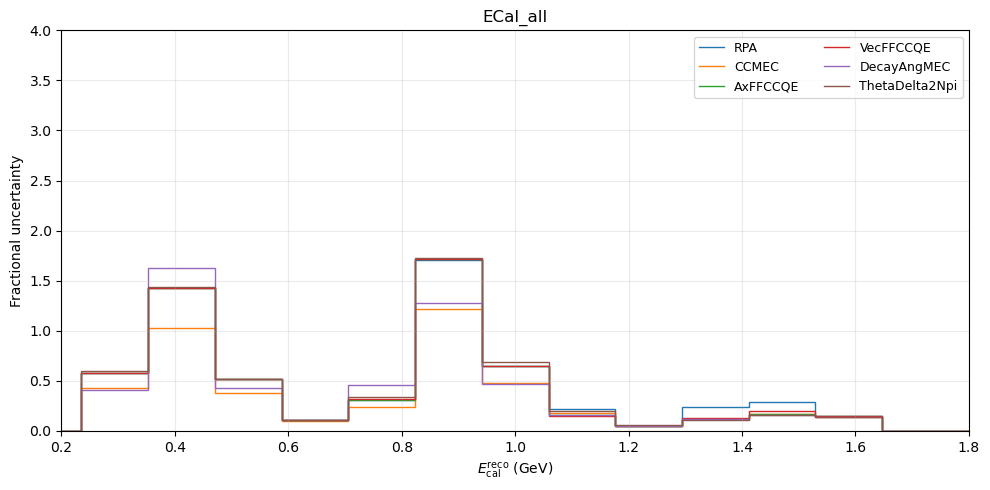

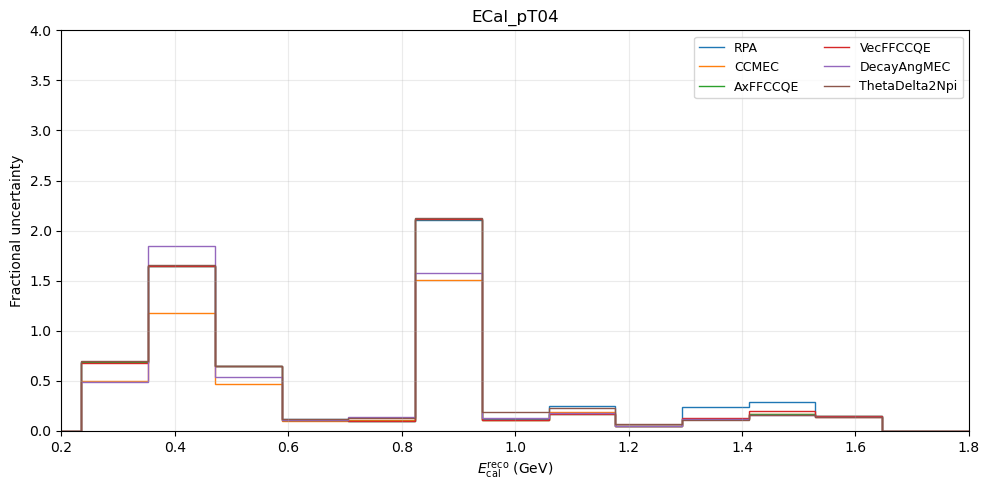

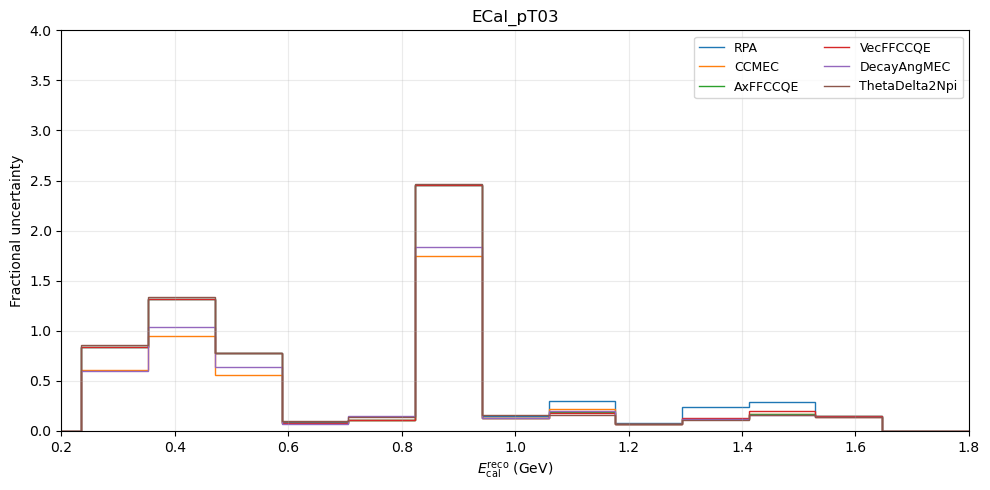

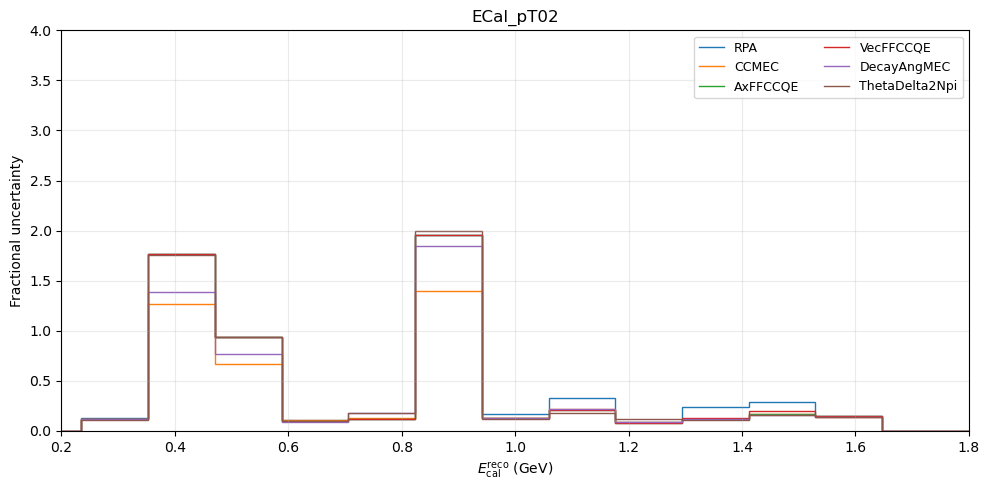

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# --- config ---
edges_ref = np.linspace(0.0, 2.0, 18)
variants = [
    ("ECal_all",  edges_ref, r"ECal (No cut)"),
    ("ECal_pT04", edges_ref, r"ECal ($p_T<0.4$)"),
    ("ECal_pT03", edges_ref, r"ECal ($p_T<0.3$)"),
    ("ECal_pT02", edges_ref, r"ECal ($p_T<0.2$)"),
]
KNOB_PAIRS = {
    "RPA"            : ("knobRPAup", "knobRPAdn"),
    "CCMEC"          : ("knobCCMECup", "knobCCMECdn"),
    "AxFFCCQE"       : ("knobAxFFCCQEup", "knobAxFFCCQEdn"),
    "VecFFCCQE"      : ("knobVecFFCCQEup", "knobVecFFCCQEdn"),
    "DecayAngMEC"    : ("knobDecayAngMECup", "knobDecayAngMECdn"),
    "ThetaDelta2Npi" : ("knobThetaDelta2Npiup", "knobThetaDelta2Npidn"),
}

mc = rundata["mc"].copy()

# Base mask from your selection/preselection
mask_sel = mc[selection].fillna(False).astype(bool)
mask_pre = mc[preselection].fillna(False).astype(bool)
mask = mask_sel & mask_pre

# Nominal per-event weight
w_nom = mc.get("weights", 1.0)
if np.isscalar(w_nom):
    w_nom = np.full(len(mc), float(w_nom))
else:
    w_nom = np.asarray(w_nom).astype(float)
w_nom = np.where(np.isfinite(w_nom), w_nom, 1.0)

def hist_counts(var_name, edges, w):
    """Histogram of MC passing selection with weights w."""
    v = mc[var_name].to_numpy()
    m = mask & np.isfinite(v)
    # also drop NaN/inf weights
    w_eff = np.where(np.isfinite(w), w, 0.0)
    H, _ = np.histogram(v[m], bins=edges, weights=w_eff[m])
    return H.astype(float)

def money_for_var(var_name, edges):
    # nominal bin contents
    mu = hist_counts(var_name, edges, w_nom)
    safe = np.where(mu > 0, mu, np.inf)

    # per-knob fractional uncertainties
    frac_by_knob = {}
    for knob, (up_col, dn_col) in KNOB_PAIRS.items():
        if up_col not in mc.columns or dn_col not in mc.columns:
            continue

        w_up = np.asarray(mc[up_col]).astype(float)
        w_dn = np.asarray(mc[dn_col]).astype(float)
        w_up = np.where(np.isfinite(w_up), w_up, 1.0)
        w_dn = np.where(np.isfinite(w_dn), w_dn, 1.0)

        H_up = hist_counts(var_name, edges, w_nom * w_up)
        H_dn = hist_counts(var_name, edges, w_nom * w_dn)

        var = 0.5 * ((H_up - mu)**2 + (H_dn - mu)**2)
        frac = np.sqrt(np.clip(var, 0, None)) / safe

        # Skip if literally no effect
        if not np.allclose(frac, 0.0):
            frac_by_knob[knob] = frac

    return mu, frac_by_knob

def plot_money(var_name, edges, xlim=(0.2,1.5), ylim=(0.0,1.0), figsize=(12,5)):
    mu, frac_by_knob = money_for_var(var_name, edges)
    if not frac_by_knob:
        print(f"[Money plot] {var_name}: no nontrivial unisim effect.")
        return

    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    fig, ax = plt.subplots(figsize=(10,5))
    for i, (knob, frac) in enumerate(frac_by_knob.items()):
        ax.stairs(frac, edges, label=knob, color=colors[i % len(colors)])
    ax.set_title(f"{var_name}")
    ax.set_xlabel(r"$E_{\mathrm{cal}}^{\mathrm{reco}}$ (GeV)")
    ax.set_ylabel("Fractional uncertainty")
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=2, fontsize=9)
    plt.tight_layout(); plt.show()

# --- run for the four variants ---
for var, edg, _ in variants:
    plot_money(var, edg, xlim=(0.2, 1.8), ylim=(0.0, 4.0), figsize=(6,4))


In [60]:
from microfit.xsec_covariances import multisim_err_with_resp_func, unisim_err_with_resp_func

m["ECal_true"]  = m["mc_Ecal"]


var_name       = "ECal_all"     # one of ECal_all, ECal_pT04, ...
true_var_name  = "ECal_true"         # <-- set to your true variable for ECal’s truth axis
edges          = np.linspace(0.0, 2.0, 18)
selection      = "sel_CC1p0pi"
preselection   = "sel_CCNp0pi"
signame        = "mc"           # or a dedicated signal sample key if you have one
truth_def      = "mc_is_signal == True"   # <-- put your actual truth signal definition

# --- 1) Multisim covariance via response method (GENIE universes) ---
C_multi = multisim_err_with_resp_func(
    rundata=rundata,
    signame=signame,
    var_name=var_name,
    true_var_name=true_var_name,
    preselection=preselection,
    selection=selection,
    truth_def=truth_def,
    bin_edges=edges,
    weightCV="weights",           # CV weights (with tune)
    base_weight_Var="weights_no_tune",
    wname="weightsGenie"          # multisim array
)

# Build the CV counts (same selection & binning)
from microfit import selections as sel
query = f"{sel.preselection_categories[preselection]['query']} and {sel.selection_categories[selection]['query']}"
cv_counts = 0
for k, df in rundata.items():
    if k in ("data","ext"): 
        continue
    d = df.query(query, engine="python")
    h, _ = np.histogram(d[var_name], bins=edges, weights=d["weights"])
    cv_counts = h if np.isscalar(cv_counts) else (cv_counts + h)

# Fractional multisim band
safe = np.where(cv_counts>0, cv_counts, np.inf)
frac_multi = np.sqrt(np.clip(np.diag(C_multi), 0, None)) / safe

# --- 2) Unisim covariance via response method (per-knob up/down) ---
C_uni = unisim_err_with_resp_func(
    rundata=rundata,
    signame=signame,
    var_name=var_name,
    true_var_name=true_var_name,
    preselection=preselection,
    selection=selection,
    truth_def=truth_def,
    bin_edges=edges,
    weightCV="weights",
    base_weight_Var="weights_no_tune",
)
frac_uni = np.sqrt(np.clip(np.diag(C_uni), 0, None)) / safe

# --- 3) Plot fractional bands (example) ---
fig, ax = plt.subplots()
ax.stairs(frac_multi, edges, label="GENIE multisim (resp.)", linestyle="--")
ax.stairs(frac_uni,   edges, label="GENIE unisim (resp.)", linestyle=":")
ax.set_xlim(0.2, 1.5); ax.set_ylim(0.0, 1.0)
ax.set_xlabel(r"$E_{\rm cal}^{\rm reco}$ (GeV)")
ax.set_ylabel("Fractional uncertainty")
ax.legend(); ax.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()


IndentationError: unindent does not match any outer indentation level (xsec_covariances.py, line 406)

In [61]:
sel1 = mc['Ecal']
sel2=  mc['mc_Ecal']
print('Ecal output from BDT: ')
print('Ecal: ',sel1)
print('mc_Ecal',sel2)



KeyError: 'mc_Ecal'

## Delta_pT

(array([ 74., 160., 130.,  83.,  63.,  57.,  38.,  24.,  12.,   4.,   1.,
          2.]),
 array([0.        , 0.08333333, 0.16666667, 0.25      , 0.33333333,
        0.41666667, 0.5       , 0.58333333, 0.66666667, 0.75      ,
        0.83333333, 0.91666667, 1.        ]),
 <BarContainer object of 12 artists>)

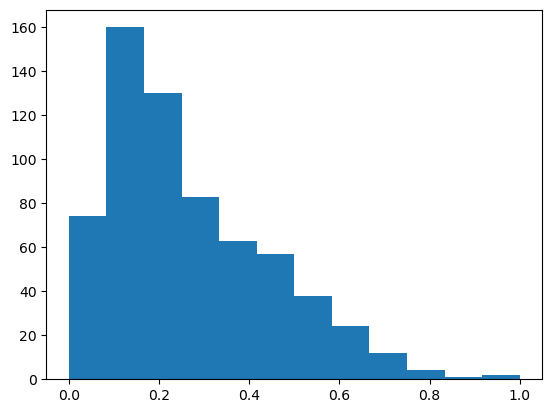

In [99]:
plt.hist(sel_mc_1mu1p["delta_pT"], bins=np.linspace(0,1,13))

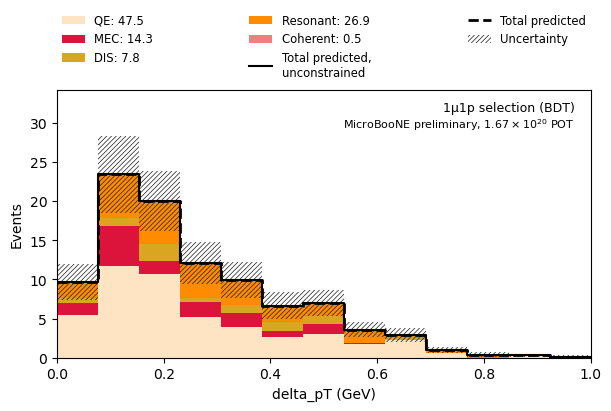

In [100]:
selection    = "sel_CC1p0pi"  
preselection = "sel_CCNp0pi"   

binning_def = ("delta_pT", 13, (0.0, 1.0), r"delta_pT (GeV)")
binning = Binning.from_config(*binning_def)
binning.label = "BDT_delta_pT"
binning.set_selection(selection, preselection)
binning

signal_generator_1mu1p = RunHistGenerator(
    rundata,
    binning,
    data_pot=data_pot,
    showdata=False,   # optional
)
total_prediction_1mu1p = signal_generator_1mu1p.get_total_prediction(include_multisim_errors=True)

from microfit.run_plotter import RunHistPlotter

plotter = RunHistPlotter(signal_generator_1mu1p)
ax = plotter.plot(
    category_column="interaction",
    include_multisim_errors=True,
    add_ext_error_floor=False,
    show_data_mc_ratio=False,
    show_chi_square=False,
)

In [101]:
for k, df in rundata.items():
    if df is None:
        continue
    # delta_pT for all events
    df["delta_pT"] = (
        sel_mc_1mu1p["delta_pT"]
    )

In [107]:
import re
import numpy as np
import pandas as pd

mc_df = rundata["mc"]

print("\n=== Columns containing 'weight' ===")
wcols = [c for c in mc_df.columns if re.search(r"weight", c, re.IGNORECASE)]
print(wcols)

# Peek structure of each weight-like column
for c in wcols:
    s = mc_df[c].dropna()
    print(f"\n--- {c} ---")
    if s.empty:
        print("  (all NaN)")
        continue
    v = s.iloc[0]
    print("  value type:", type(v))
    try:
        print("  len(value):", len(v))
    except Exception:
        pass

    if isinstance(v, dict):
        keys = list(v.keys())
        print("  dict keys (sample):", keys[:20])
    elif isinstance(v, (list, tuple, np.ndarray, pd.Series)):
        arr = np.asarray(v)
        print("  array shape:", arr.shape, " first 5:", arr[:5])
    else:
        print("  scalar-like preview:", v)

# See if per-knob columns exist (e.g., weightsGenie__<knob>, etc.)
knob_names = [
        "knobRPAup",
        "knobRPAdn",
        "knobCCMECup",
        "knobCCMECdn",
        "knobAxFFCCQEup",
        "knobAxFFCCQEdn",
        "knobVecFFCCQEup",
        "knobVecFFCCQEdn",
        "knobDecayAngMECup",
        "knobDecayAngMECdn",
        "knobThetaDelta2Npiup",
        "knobThetaDelta2Npidn",
]

print("\n=== Per-knob column name matches ===")
for knob in knob_names:
    matches = [c for c in mc_df.columns if knob in c]
    print(f"{knob:>28}: {matches}")

# Look for a companion *labels* column that maps universes -> knob names
labelish = [c for c in mc_df.columns if re.search(r"(label|name|key)", c, re.IGNORECASE) and "genie" in c.lower()]
print("\n=== Possible label columns near GENIE ===")
print(labelish)

# If your analysis stores a metadata mapping on the object, try to discover it:
try:
    mc_hg = None
    from microfit import histogram as hist
    # build a tiny dummy binning to instantiate a hist generator
    tiny_bin = hist.Binning(variable="delta_pT" if "delta_pT" in mc_df.columns else "delta_pT",
                            bin_edges=np.linspace(0,2,3), label="tmp", variable_tex="tmp")
    _hg = hist.RunHistGenerator(rundata, tiny_bin, data_pot=data_pot,
                                selection="sel_CC1p0pi", preselection="sel_CCNp0pi",
                                showdata=False)
    mc_hg = _hg.mc_hist_generator

    meta_attrs = [a for a in dir(mc_hg) if any(k in a.lower() for k in ["genie","multisim","weight","knob","map","index","meta"])]
    print("\n=== mc_hist_generator attributes that might be useful ===")
    print(meta_attrs[:50])

    # Print any obvious mapping-looking attributes
    for name in meta_attrs:
        try:
            val = getattr(mc_hg, name)
            if isinstance(val, (dict, list, tuple)):
                print(f"\n>>> {name} (type={type(val).__name__}, len={len(val)})")
                if isinstance(val, dict):
                    print("keys (sample):", list(val.keys())[:20])
                else:
                    print("sample:", val[:5])
        except Exception:
            pass
except Exception as e:
    print("\n[info] Could not instantiate mc_hist_generator for introspection:", e)



=== Columns containing 'weight' ===
['weightSpline', 'weightTune', 'weightsFlux', 'weightsReint', 'weightsGenie', 'weightSplineTimesTune', 'weightMCC8', 'pi0weight', 'weights', 'weights_no_tune']

--- weightSpline ---
  value type: <class 'numpy.float32'>
  scalar-like preview: 1.0

--- weightTune ---
  value type: <class 'numpy.float32'>
  scalar-like preview: 1.0

--- weightsFlux ---
  value type: <class 'numpy.ndarray'>
  len(value): 100
  array shape: (100,)  first 5: [1105 1128 1208 1295 1087]

--- weightsReint ---
  value type: <class 'numpy.ndarray'>
  len(value): 100
  array shape: (100,)  first 5: [ 995  986 1007 1000  993]

--- weightsGenie ---
  value type: <class 'numpy.ndarray'>
  len(value): 100
  array shape: (100,)  first 5: [ 842  418  603 1168 1614]

--- weightSplineTimesTune ---
  value type: <class 'numpy.float32'>
  scalar-like preview: 1.0

--- weightMCC8 ---
  value type: <class 'numpy.float64'>
  scalar-like preview: 1.5384615384615383

--- pi0weight ---
  valu

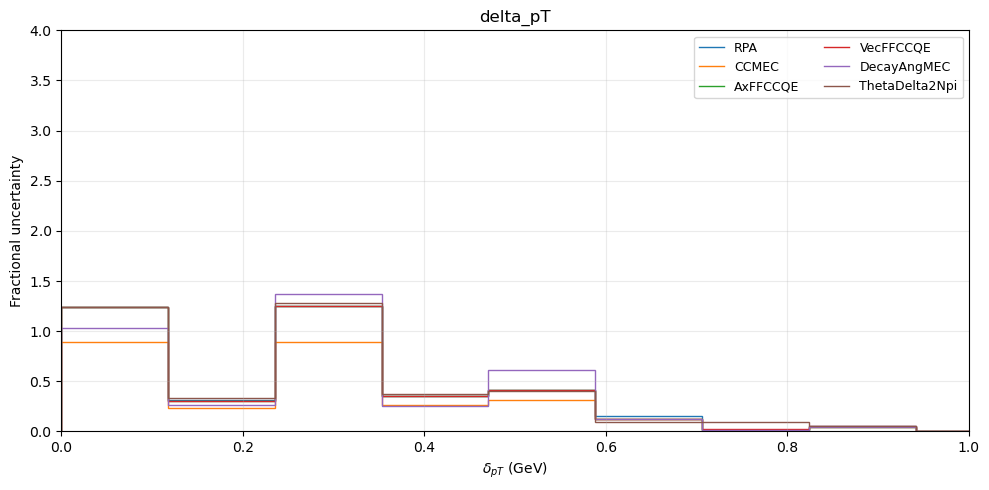

In [108]:
import numpy as np
import matplotlib.pyplot as plt

# --- config ---
edges_ref = np.linspace(0.0, 2.0, 18)
variants = [
    ("delta_pT",  edges_ref, r"delta_pT"),
]
KNOB_PAIRS = {
    "RPA"            : ("knobRPAup", "knobRPAdn"),
    "CCMEC"          : ("knobCCMECup", "knobCCMECdn"),
    "AxFFCCQE"       : ("knobAxFFCCQEup", "knobAxFFCCQEdn"),
    "VecFFCCQE"      : ("knobVecFFCCQEup", "knobVecFFCCQEdn"),
    "DecayAngMEC"    : ("knobDecayAngMECup", "knobDecayAngMECdn"),
    "ThetaDelta2Npi" : ("knobThetaDelta2Npiup", "knobThetaDelta2Npidn"),
}

mc = rundata["mc"].copy()

# Base mask from your selection/preselection
mask_sel = mc[selection].fillna(False).astype(bool)
mask_pre = mc[preselection].fillna(False).astype(bool)
mask = mask_sel & mask_pre

# Nominal per-event weight
w_nom = mc.get("weights", 1.0)
if np.isscalar(w_nom):
    w_nom = np.full(len(mc), float(w_nom))
else:
    w_nom = np.asarray(w_nom).astype(float)
w_nom = np.where(np.isfinite(w_nom), w_nom, 1.0)

def hist_counts(var_name, edges, w):
    """Histogram of MC passing selection with weights w."""
    v = mc[var_name].to_numpy()
    m = mask & np.isfinite(v)
    # also drop NaN/inf weights
    w_eff = np.where(np.isfinite(w), w, 0.0)
    H, _ = np.histogram(v[m], bins=edges, weights=w_eff[m])
    return H.astype(float)

def money_for_var(var_name, edges):
    # nominal bin contents
    mu = hist_counts(var_name, edges, w_nom)
    safe = np.where(mu > 0, mu, np.inf)

    # per-knob fractional uncertainties
    frac_by_knob = {}
    for knob, (up_col, dn_col) in KNOB_PAIRS.items():
        if up_col not in mc.columns or dn_col not in mc.columns:
            continue

        w_up = np.asarray(mc[up_col]).astype(float)
        w_dn = np.asarray(mc[dn_col]).astype(float)
        w_up = np.where(np.isfinite(w_up), w_up, 1.0)
        w_dn = np.where(np.isfinite(w_dn), w_dn, 1.0)

        H_up = hist_counts(var_name, edges, w_nom * w_up)
        H_dn = hist_counts(var_name, edges, w_nom * w_dn)

        var = 0.5 * ((H_up - mu)**2 + (H_dn - mu)**2)
        frac = np.sqrt(np.clip(var, 0, None)) / safe

        # Skip if literally no effect
        if not np.allclose(frac, 0.0):
            frac_by_knob[knob] = frac

    return mu, frac_by_knob

def plot_money(var_name, edges, xlim=(0.2,1.5), ylim=(0.0,1.0), figsize=(12,5)):
    mu, frac_by_knob = money_for_var(var_name, edges)
    if not frac_by_knob:
        print(f"[Money plot] {var_name}: no nontrivial unisim effect.")
        return

    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    fig, ax = plt.subplots(figsize=(10,5))
    for i, (knob, frac) in enumerate(frac_by_knob.items()):
        ax.stairs(frac, edges, label=knob, color=colors[i % len(colors)])
    ax.set_title(f"{var_name}")
    ax.set_xlabel(r"$\delta_{pT}$ (GeV)")
    ax.set_ylabel("Fractional uncertainty")
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.grid(True, alpha=0.25)
    ax.legend(ncol=2, fontsize=9)
    plt.tight_layout(); plt.show()

# --- run for the four variants ---
for var, edg, _ in variants:
    plot_money(var, edg, xlim=(0.0, 1.0), ylim=(0.0, 4.0), figsize=(6,4))
